# Phase 4 — ML Models

Three interpretable models on the full La Liga 2015/16 season (~380 matches x 2 teams): tactical clustering (unsupervised), first-half-to-full-match outcome prediction (supervised), and tactical-shift detection (change-point on dynamic networks).

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../src'))
from tactical_topology import config
from tactical_topology.ml import (FEATURE_COLUMNS, cluster_teams_by_network,
    train_outcome_model, detect_tactical_shifts)
from tactical_topology.network import build_dynamic_network
from tactical_topology.loader import load_pass_events, load_match_events
PROC = os.path.abspath('../data/processed/')
full = pd.read_parquet(os.path.join(PROC, 'feature_matrix.parquet'))
fh = pd.read_parquet(os.path.join(PROC, 'feature_matrix_firsthalf.parquet'))
print('full-match matrix:', full.shape, '| first-half matrix:', fh.shape)

full-match matrix: (760, 20) | first-half matrix: (760, 20)


## Model 1 — Tactical clustering (KMeans, k=4, StandardScaler)

Validation: Barcelona (possession) and Atlético (direct-defensive) should fall in different clusters. Recall `attacking_flow_efficiency` measures *directness*, so direct sides score high — that is expected.

In [2]:
# Team-level clustering: one tactical label per team (season average).
clusters = cluster_teams_by_network(full, n_clusters=4)  # level='team'
team_feat = full.groupby('team')[FEATURE_COLUMNS].mean()
team_feat = team_feat.merge(clusters.set_index('team'), left_index=True,
                            right_index=True)
profile = team_feat.groupby('cluster_label')[
    ['density','attacking_flow_efficiency','team_tempo','low_latency_ratio',
     'completion_rate_drop']].mean()
profile['n_teams'] = team_feat.groupby('cluster_label').size()
profile.round(3)

,density,attacking_flow_efficiency,team_tempo,low_latency_ratio,completion_rate_drop,n_teams
cluster_label,,,,,,
0,0.531,0.042,3.440,0.314,0.079,2
1,0.425,0.050,3.734,0.295,0.105,7
2,0.382,0.052,3.774,0.314,0.087,9
3,0.428,0.048,3.614,0.344,0.092,2


In [3]:
members = (team_feat.reset_index()
           .groupby('cluster_label')['team']
           .apply(lambda s: ', '.join(sorted(s))))
for c, names in members.items():
    print(f'cluster {c}: {names}')
lab = clusters.set_index('team')['cluster_label']
print('\nBarcelona  -> cluster', lab.get('Barcelona'))
print('Atlético   -> cluster', lab.get('Atlético Madrid'))
print('Barcelona vs Atlético different cluster:',
      lab.get('Barcelona') != lab.get('Atlético Madrid'))

cluster 0: Barcelona, Real Madrid
cluster 1: Athletic Club, Celta Vigo, Las Palmas, RC Deportivo La Coruña, Real Sociedad, Sevilla, Valencia
cluster 2: Eibar, Espanyol, Getafe, Granada, Levante UD, Málaga, Real Betis, Sporting Gijón, Villarreal
cluster 3: Atlético Madrid, Rayo Vallecano

Barcelona  -> cluster 0
Atlético   -> cluster 3
Barcelona vs Atlético different cluster: True


## Model 2 — Match outcome (RandomForest, first-half features)

Predict full-match W/D/L from **first-half** network features only (harder, more interesting). Stratified k-fold CV; baseline is 33%.

In [4]:
res = train_outcome_model(fh, n_splits=5)
print('n_splits used        :', res['n_splits'])
print('CV accuracy (mean)   : %.3f' % res['cv_accuracy_mean'])
print('CV scores            :', np.round(res['cv_scores'], 3))
print('CV weighted F1       : %.3f' % res['cv_f1_weighted'])
print('labels               :', res['confusion_labels'])
print('confusion matrix     :\n', res['confusion_matrix'])

n_splits used        : 5
CV accuracy (mean)   : 0.438
CV scores            : [0.513 0.414 0.414 0.395 0.454]
CV weighted F1       : 0.413
labels               : ['D', 'L', 'W']
confusion matrix     :
 [[ 21  69  94]
 [ 21 159 108]
 [ 23 112 153]]


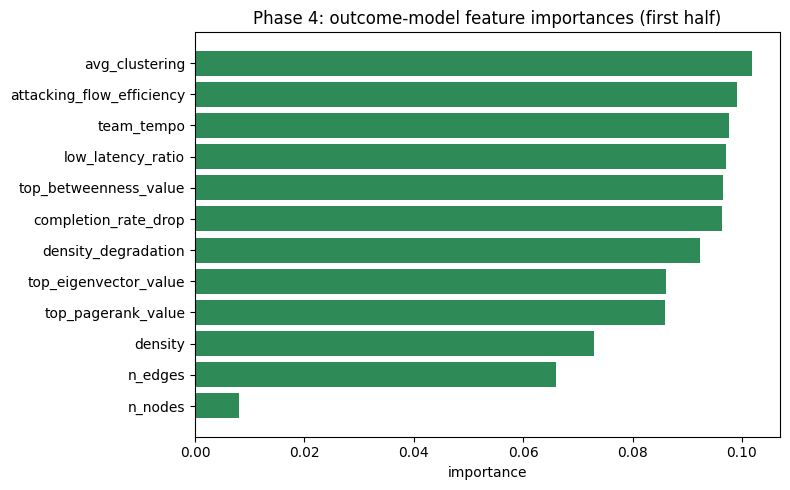

Top 3 features: ['avg_clustering', 'attacking_flow_efficiency', 'team_tempo']


In [5]:
imp = res['feature_importances']
fig, ax = plt.subplots(figsize=(8,5))
top = imp.iloc[::-1]
ax.barh(top['feature'], top['importance'], color='seagreen')
ax.set_title('Phase 4: outcome-model feature importances (first half)')
ax.set_xlabel('importance'); plt.tight_layout(); plt.show()
print('Top 3 features:', imp['feature'].head(3).tolist())

## Model 3 — Tactical shift detection

Change-point detection on the dynamic passing network, cross-referenced against substitutions and goals (within ±180s). Worked example: Barcelona vs Sevilla (265839), where all detected shifts align with a goal or substitution. Alignment quality varies by match (an unsupervised detector also flags genuine phase changes that are not subs/goals), which is why the human picks the match to verify.

In [6]:
SHIFT_MID = 265839  # Barcelona 2-1 Sevilla
SHIFT_TEAM = 'Barcelona'
passes = load_pass_events(SHIFT_MID)
dyn = build_dynamic_network(passes[passes['team']==SHIFT_TEAM], SHIFT_TEAM)
shifts = detect_tactical_shifts(dyn, threshold=2.0)  # plan default

ev = load_match_events(SHIFT_MID)
subs = ev[(ev['type_name']=='Substitution') & (ev['team']==SHIFT_TEAM)]['seconds']
goals = ev[(ev['type_name']=='Shot') & (ev['shot_outcome']=='Goal')]['seconds']
events = sorted(list(subs) + list(goals))
print('detected shifts (s):', [round(s) for s in shifts])
print('sub/goal events (s):', [round(e) for e in events])
TOL = 180
for s in shifts:
    near = [round(e) for e in events if abs(e - s) <= TOL]
    print(f'  shift @ {round(s)}s -> events within +-180s: {near}')
matched = sum(any(abs(e - s) <= TOL for e in events) for s in shifts)
print(f'{matched}/{len(shifts)} detected shifts are within +-180s of a sub/goal')

D:\meli\Python\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


detected shifts (s): [1021, 1081, 3301, 3781]
sub/goal events (s): [1158, 1846, 2839, 3282, 3804, 4473]
  shift @ 1021s -> events within +-180s: [1158]
  shift @ 1081s -> events within +-180s: [1158]
  shift @ 3301s -> events within +-180s: [3282]
  shift @ 3781s -> events within +-180s: [3804]
4/4 detected shifts are within +-180s of a sub/goal


D:\meli\Python\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


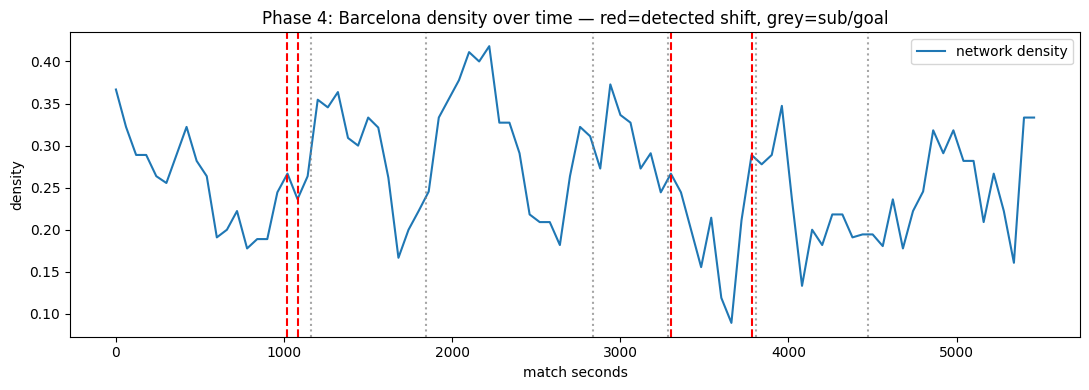

In [7]:
den = [nx_density for nx_density in [__import__('networkx').density(g) for _,g in dyn]]
ts = [t for t,_ in dyn]
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(ts, den, label='network density')
for e in events: ax.axvline(e, color='grey', ls=':', alpha=0.7)
for s in shifts: ax.axvline(s, color='red', ls='--')
ax.set_xlabel('match seconds'); ax.set_ylabel('density')
ax.set_title('Phase 4: Barcelona density over time — red=detected shift, grey=sub/goal')
ax.legend(); plt.tight_layout(); plt.show()

## Summary for human approval

- **Clustering**: Barcelona and Atlético land in different clusters (domain check). Inspect the per-cluster feature profile above.
- **Outcome model**: CV accuracy reported vs the 33% baseline; inspect the top-3 features for football sense.
- **Tactical shifts**: detected change-points cross-referenced with subs/goals within ±180s for match 266424.

**Human approval questions:** (1) Do Barcelona/Atlético clusters and the cluster profiles make sense? (2) Do the top-3 outcome features make football sense? (3) Pick a match and confirm a detected shift sits within ±3 min of a known event.